<a href="https://colab.research.google.com/github/Mahima-Bachhav/Reinforcement_Basics/blob/main/Atari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !apt-get install x11-utils > /dev/null 2>&1
# !pip install pyglet > /dev/null 2>&1
# !apt-get install -y xvfb python-opengl > /dev/null 2>&1a

In [ ]:
# !pip install gym pyvirtualdisplay > /dev/null 2>&1

In [ ]:
import gymnasium as gym

In [ ]:
!pip install "gymnasium[atari, accept-rom-license]"


In [ ]:
!pip install ale-py


In [ ]:
import ale_py
gym.register_envs(ale_py)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay

In [ ]:
# from pyvirtualdisplay import Display
# display = Display(visible=0, size=(400, 300))
# display.start()

In [ ]:
from gymnasium.wrappers import AtariPreprocessing,FrameStackObservation

In [ ]:
env = gym.make("ALE/Pong-v5", render_mode='rgb_array',obs_type="grayscale",frameskip=1)
env = AtariPreprocessing(
    env,
    noop_max=10, frame_skip=4, terminal_on_life_loss=True,
    screen_size=84, grayscale_obs=True, grayscale_newaxis=False,scale_obs=True
)
env = FrameStackObservation(env,4)

In [ ]:
env.observation_space

Box(0.0, 1.0, (4, 84, 84), float32)

In [ ]:
obs, info = env.reset()

print("Observation shape:", obs.shape)

Observation shape: (4, 84, 84)


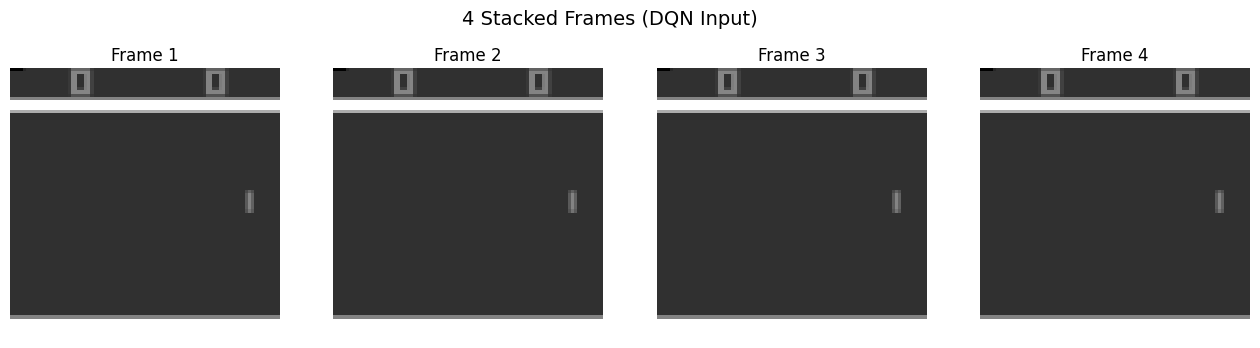

In [ ]:
def show_stacked_frames(stacked_obs):
    """
    stacked_obs: shape (4, 84, 84)
    shows each of the 4 frames separately
    """
    frames = np.array(stacked_obs)  # convert LazyFrames to numpy

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for i in range(4):
        axes[i].imshow(frames[i], cmap="gray")
        axes[i].set_title(f"Frame {i+1}")
        axes[i].axis("off")

    plt.suptitle("4 Stacked Frames (DQN Input)", fontsize=14)
    plt.show()

show_stacked_frames(obs)


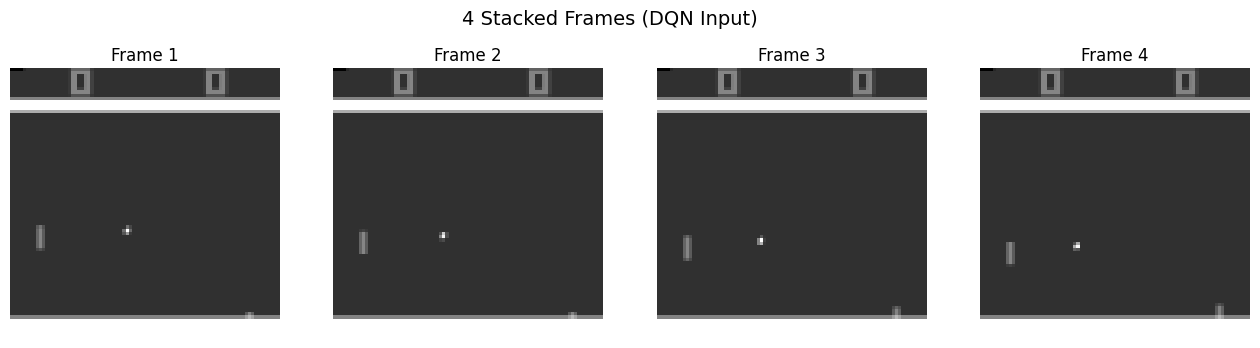

In [ ]:
obs, _ = env.reset()

for _ in range(20):
    obs, _, terminated, truncated, _ = env.step(env.action_space.sample())
    if terminated or truncated:
        obs, _ = env.reset()

show_stacked_frames(obs)


In [ ]:
import torch
import torch.nn.functional as F
from torch import nn


In [ ]:
# env.action_space.n

In [ ]:
class CNN(nn.Module):
  def __init__(self,in_channels,out_size=env.action_space.n):
    super(CNN,self).__init__()
    self.conv1 = nn.Conv2d(in_channels,32,8,4,0)
    self.conv2 = nn.Conv2d(32,64,4,2,0)
    self.conv3 = nn.Conv2d(64,64,3,1,0)
    self.flat = nn.Flatten()
    self.fc1 = nn.Linear(64*7*7,512)
    self.fc2 = nn.Linear(512,out_size)

  def forward(self,x):
    x = F.relu(self.conv1(x))
    x = F.relu(self.conv2(x))
    x = F.relu(self.conv3(x))
    x = self.flat(x)
    x = F.relu(self.fc1(x))
    x = self.fc2(x)

    return x

In [ ]:
buffer_capacity = 100000
states = torch.empty(buffer_capacity,4,84,84,dtype=torch.uint8)
actions = torch.empty(buffer_capacity,dtype=torch.int32)
rewards = torch.empty(buffer_capacity,dtype = torch.float32)
next_states = torch.empty(buffer_capacity,4,84,84,dtype=torch.uint8)
dones = torch.empty(buffer_capacity,dtype=torch.bool)
pos = 0
size = 0

In [ ]:
def store_transition(state,action,reward,n_state,done_flag,pos,size):
  global states, actions, rewards, next_states, dones
  states[pos] = torch.as_tensor(state,dtype=torch.uint8)
  actions[pos] = action
  rewards[pos] = reward
  next_states[pos] = torch.as_tensor(n_state,dtype=torch.uint8)
  dones[pos] = done_flag
  pos = (pos+1)%buffer_capacity
  size = min(size + 1, buffer_capacity)
  return pos,size

In [ ]:
obs,_ = env.reset()
for _ in range(10000):
  action = env.action_space.sample()
  n_state,reward,terminated,truncated,_ = env.step(action)
  done_flag = terminated or truncated
  pos,size = store_transition(obs,action,reward,n_state,done_flag,pos,size)
  if done_flag:
    obs,_ = env.reset()
  else: obs = n_state

env.close()

In [ ]:
actions.shape

torch.Size([100000])

In [ ]:
size

10000

In [ ]:
def sample_batch(batch_size,size):
  random_indices = torch.randint(low=0,high=size,size=(batch_size,),dtype = torch.long)
  # print(f"Generated indices: {random_indices}")
  batch_states = states[random_indices]
  batch_states = batch_states.to(torch.float32)/255.0
  batch_actions = actions[random_indices]
  batch_rewards = rewards[random_indices]
  batch_nextStates = next_states[random_indices].to(torch.float32)/255.0
  batch_dones = dones[random_indices]
  return batch_states,batch_actions,batch_rewards,batch_nextStates,batch_dones

In [ ]:
# bs,ba,br,bn,bd = sample_batch(3,size)

In [ ]:
# bs.shape

In [ ]:
num_actions = env.action_space.n

In [ ]:
online_net = CNN(in_channels=4,out_size=num_actions)

In [ ]:
target_net = CNN(in_channels=4, out_size=num_actions)

In [ ]:
target_net.load_state_dict(online_net.state_dict())

<All keys matched successfully>

In [ ]:
target_net.eval()

CNN(
  (conv1): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
  (conv2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (flat): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=6, bias=True)
)

In [ ]:
# online_net(torch.as_tensor(env.observation_space.sample(), dtype=torch.float32).unsqueeze(0))

In [ ]:
def greedy_action(Q_online,state):
  state = torch.as_tensor(state,dtype=torch.float32).unsqueeze(0)
  state = state/255.0
  with torch.no_grad():
    q = Q_online(state)
  action = int(torch.argmax(q, dim=1).item())
  return action

In [ ]:
import random
def epsilon_greedy_policy(Q_online,state,epsilon,env):
  rnd_num = random.uniform(0,1)
  if rnd_num>epsilon:
    action = greedy_action(Q_online,state)
  else:
    action = env.action_space.sample()
  return action

In [ ]:
train_eps = 200
lr = 1e-4
eval_eps = 100
max_steps = 500
gamma = 0.95
eval_seed = []
max_epsilon = 1.0
min_epsilon = 0.05
decay_rate = 0.0005
batch_size = 32
target_update_freq = 1000
global_step = 0
train_freq = 4
target_update_freq=2000
optimizer = torch.optim.Adam(params=online_net.parameters(),lr=lr)
loss_fn = torch.nn.HuberLoss()

In [ ]:
from collections import deque
from tqdm import tqdm
def train(train_eps, max_epsilon, min_epsilon, decay_rate, env, max_steps,
          Q_online, Q_target, batch_size, gamma,
          train_freq, target_update_freq):
  global pos, size, global_step
  episode_rewards = []
  recent_rewards = deque(maxlen=100)
  for i in tqdm(range(train_eps)):
    epsilon = min_epsilon + (max_epsilon-min_epsilon)*np.exp(-decay_rate*i)
    state,_ = env.reset()
    ep_reward = 0
    for t in range(max_steps):
      action = epsilon_greedy_policy(Q_online,state,epsilon,env)
      new_state, reward, terminated, truncated, _ = env.step(action)
      done_flag = terminated or truncated
      ep_reward += reward
      pos, size = store_transition(state, action, reward, new_state, done_flag, pos, size)
      state = new_state
      global_step += 1

      if size>=batch_size:
        bs, ba, br, bns, bd = sample_batch(batch_size, size)
        q_values = Q_online(bs)
        q_sa = q_values.gather(1, ba.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
          next_q_values = Q_target(bns)
          max_next_q = next_q_values.max(dim=1)[0]
          target = br + gamma * (1 - bd.float()) * max_next_q


        loss = loss_fn(q_sa, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

      if global_step % target_update_freq == 0:
            Q_target.load_state_dict(Q_online.state_dict())

      if done_flag:
          break

    episode_rewards.append(ep_reward)
    recent_rewards.append(ep_reward)

    if (i + 1) % 100 == 0:
        avg100 = np.mean(recent_rewards)
        print(f"Episode {i+1} | Avg(100): {avg100:.3f} | Epsilon: {epsilon:.3f} | Buffer size: {size}")
  return Q_online, episode_rewards

In [ ]:
online_net,rewards_history = train(train_eps,max_epsilon,min_epsilon,decay_rate,env,max_steps,online_net,target_net,batch_size,gamma,train_freq,target_update_freq)

 26%|██▌       | 52/200 [29:26<1:25:28, 34.65s/it]

In [ ]:
rewards_history

In [ ]:
import matplotlib.pyplot as plt

plt.plot(rewards_history)
plt.xlabel("Episode")
plt.ylabel("Episode Reward")
plt.title("Training Reward Curve")
plt.show()